# Feature Engineering v3 — Dataset Open-Meteo
**David, Chiriquí 1940–2026**

Versión limpia — solo 5 targets de regresión:
- ✅ Target_Temp_Prom
- ✅ Target_Humedad
- ✅ Target_Lluvia
- ✅ Target_Viento_Max
- ✅ Target_Presion

El índice de calor y nivel de alerta se calculan matemáticamente
a partir de los valores predichos — no son modelos separados.

## 1. Configuración del entorno

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# ============================================
# CONFIGURACIÓN DE RUTAS
# ============================================

BASE_DIR = Path.cwd().parent

DATA_PROCESSED = BASE_DIR / "data" / "processed"

REPORTS_DIR = BASE_DIR / "reports"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ============================================
# ARCHIVOS
# ============================================

INPUT_FILE = DATA_PROCESSED / "dataset_limpio.csv"

OUTPUT_FILE = DATA_PROCESSED / "dataset_features.csv"

print("BASE_DIR:")
print(BASE_DIR)

print("\nINPUT:")
print(INPUT_FILE)



BASE_DIR:
c:\Users\Yajaira\Desktop\PROYECTO_PREDICCION_IA

INPUT:
c:\Users\Yajaira\Desktop\PROYECTO_PREDICCION_IA\data\processed\dataset_limpio.csv


## 2. Carga del dataset unido

In [11]:
# ============================================
# CARGAR DATASET LIMPIO
# ============================================

df_hora = pd.read_csv(INPUT_FILE)

# Convertir columna de fecha
df_hora["time"] = pd.to_datetime(df_hora["time"])

# Ordenar cronológicamente
df_hora = (
    df_hora
    .sort_values("time")
    .reset_index(drop=True)
)

# ============================================
# INFORMACIÓN GENERAL
# ============================================

print("Dataset horario cargado correctamente")

print(f"\nFilas:")
print(f"{len(df_hora):,}")

print(f"\nColumnas:")
print(df_hora.columns.tolist())

print(f"\nRango temporal:")
print(
    f"{df_hora['time'].min()} "
    f"→ "
    f"{df_hora['time'].max()}"
)

# Mostrar primeras filas
df_hora.head(3)

Dataset horario cargado correctamente

Filas:
318,984

Columnas:
['time', 'temperature', 'humidity', 'rain', 'pressure', 'wind_speed', 'year', 'month', 'day', 'hour', 'date']

Rango temporal:
1990-01-01 00:00:00 → 2026-05-22 23:00:00


,time,temperature,humidity,rain,pressure,wind_speed,year,month,day,hour,date
0,1990-01-01 00:00:00,21.5,92,0.0,1008.3,6.2,1990,1,1,0,1990-01-01
1,1990-01-01 01:00:00,21.4,91,0.0,1008.0,7.1,1990,1,1,1,1990-01-01
2,1990-01-01 02:00:00,21.6,88,0.0,1007.5,7.2,1990,1,1,2,1990-01-01


## 3. Agregación horaria → diaria

In [12]:
df_hora['Fecha'] = df_hora['time'].dt.date

df = df_hora.groupby('Fecha').agg(
    Temp_Max   = ('temperature', 'max'),
    Temp_Min   = ('temperature', 'min'),
    Temp_Prom  = ('temperature', 'mean'),
    Humedad    = ('humidity',    'mean'),
    Lluvia     = ('rain',        'sum'),
    Presion    = ('pressure',    'mean'),
    Viento_Max = ('wind_speed',  'max'),
).reset_index()

df['Fecha']      = pd.to_datetime(df['Fecha'])
df['Temp_Max']   = df['Temp_Max'].round(1)
df['Temp_Min']   = df['Temp_Min'].round(1)
df['Temp_Prom']  = df['Temp_Prom'].round(1)
df['Humedad']    = df['Humedad'].round(1)
df['Lluvia']     = df['Lluvia'].round(1)
df['Presion']    = df['Presion'].round(1)
df['Viento_Max'] = df['Viento_Max'].round(1)

print(f'Filas diarias : {len(df):,}')
print(f'Rango         : {df["Fecha"].min().date()} → {df["Fecha"].max().date()}')
print()
print('Estadísticas básicas:')
print(df[['Temp_Max','Temp_Min','Temp_Prom','Humedad','Lluvia','Presion','Viento_Max']].describe().round(1).loc[['min','mean','max']])

Filas diarias : 13,291
Rango         : 1990-01-01 → 2026-05-22

Estadísticas básicas:
      Temp_Max  Temp_Min  Temp_Prom  Humedad  Lluvia  Presion  Viento_Max
min       22.5      18.4       21.7     37.4     0.0    999.3         3.4
mean      29.7      22.2       25.3     81.9    10.7   1005.6         8.8
max       38.1      26.2       30.2     99.6   200.0   1010.0        32.7


## 4. Índice de calor y nivel de alerta — solo para referencia en el dataset

Índice de calor y nivel de alerta calculados (solo referencia).

Distribución histórica de niveles:
  PELIGRO             :  6077 días (45.7%)
  PRECAUCION          :  2748 días (20.7%)
  PELIGRO EXTREMO     :  2498 días (18.8%)
  NORMAL              :  1968 días (14.8%)


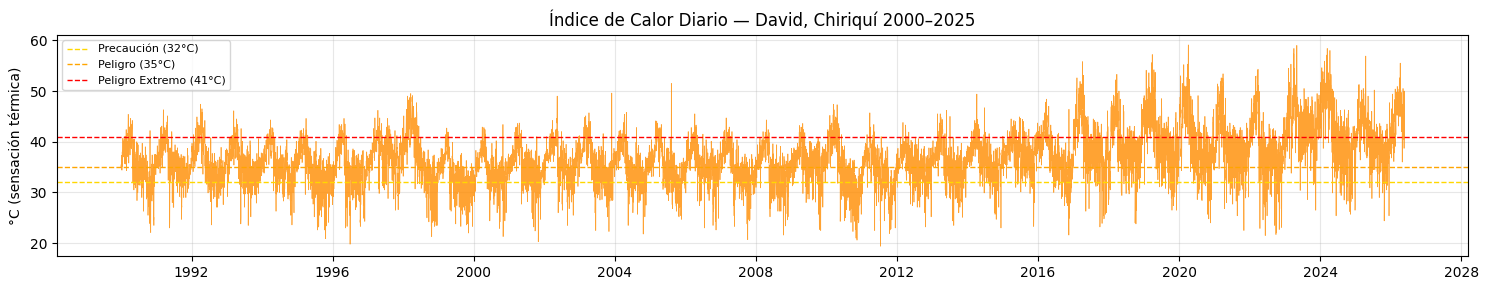

Gráfica guardada en reports/


In [13]:
# Se calculan para referencia visual pero NO serán targets del modelo
T = df['Temp_Max']
H = df['Humedad']

df['Indice_Calor'] = (
    -8.78469475556
    + 1.61139411      * T
    + 2.33854883889   * H
    - 0.14611605      * T * H
    - 0.012308094     * T**2
    - 0.0164248277778 * H**2
    + 0.002211732     * T**2 * H
    + 0.00072546      * T    * H**2
    - 0.000003582     * T**2 * H**2
).round(1)

def nivel_alerta(ic):
    if ic >= 41: return 'PELIGRO EXTREMO'
    elif ic >= 35: return 'PELIGRO'
    elif ic >= 32: return 'PRECAUCION'
    else: return 'NORMAL'

df['Nivel_Alerta'] = df['Indice_Calor'].apply(nivel_alerta)

print('Índice de calor y nivel de alerta calculados (solo referencia).')
print()
print('Distribución histórica de niveles:')
conteo = df['Nivel_Alerta'].value_counts()
for nivel, cantidad in conteo.items():
    pct = cantidad / len(df) * 100
    print(f'  {nivel:20s}: {cantidad:5d} días ({pct:.1f}%)')


plt.figure(figsize=(15, 3))
plt.plot(df['Fecha'], df['Indice_Calor'], color='darkorange', linewidth=0.5, alpha=0.8)
plt.axhline(y=32, color='gold',   linestyle='--', linewidth=1, label='Precaución (32°C)')
plt.axhline(y=35, color='orange', linestyle='--', linewidth=1, label='Peligro (35°C)')
plt.axhline(y=41, color='red',    linestyle='--', linewidth=1, label='Peligro Extremo (41°C)')
plt.title('Índice de Calor Diario — David, Chiriquí 2000–2025')
plt.ylabel('°C (sensación térmica)')
plt.legend(loc='upper left', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'indice_calor_openmeteo.png', dpi=150)
plt.show()
print('Gráfica guardada en reports/')

## 5. Variables de calendario

In [14]:
df['Dia_Año']      = df['Fecha'].dt.dayofyear
df['Mes_Num']      = df['Fecha'].dt.month
df['Estacion_Num'] = df['Mes_Num'].apply(lambda m: 1 if m in [12,1,2,3,4] else 0)
df['Lluvia_Hist']  = df['Dia_Año'].map(df.groupby('Dia_Año')['Lluvia'].mean().round(2))

print('Variables de calendario creadas.')

Variables de calendario creadas.


## 6. Lags

In [15]:
df['Temp_Prom_lag1']  = df['Temp_Prom'].shift(1)
df['Temp_Prom_lag7']  = df['Temp_Prom'].shift(7)
df['Temp_Prom_lag30'] = df['Temp_Prom'].shift(30)
df['Temp_Max_lag1']   = df['Temp_Max'].shift(1)
df['Temp_Max_lag7']   = df['Temp_Max'].shift(7)
df['IC_lag1']         = df['Indice_Calor'].shift(1)
df['IC_lag7']         = df['Indice_Calor'].shift(7)
df['Lluvia_lag1']     = df['Lluvia'].shift(1)
df['Lluvia_lag7']     = df['Lluvia'].shift(7)
df['Viento_lag1']     = df['Viento_Max'].shift(1)
df['Humedad_lag1']    = df['Humedad'].shift(1)
df['Humedad_lag7']    = df['Humedad'].shift(7)
df['Presion_lag1']    = df['Presion'].shift(1)

print('Lags creados correctamente.')

Lags creados correctamente.


## 7. Medias móviles

In [16]:
df['Temp_Prom_m7']  = df['Temp_Prom'].rolling(7).mean().round(2)
df['Temp_Prom_m30'] = df['Temp_Prom'].rolling(30).mean().round(2)
df['Temp_Max_m7']   = df['Temp_Max'].rolling(7).mean().round(2)
df['IC_m7']         = df['Indice_Calor'].rolling(7).mean().round(2)
df['IC_m30']        = df['Indice_Calor'].rolling(30).mean().round(2)
df['Lluvia_m7']     = df['Lluvia'].rolling(7).mean().round(2)
df['Lluvia_m30']    = df['Lluvia'].rolling(30).mean().round(2)
df['Humedad_m7']    = df['Humedad'].rolling(7).mean().round(2)
df['Presion_m7']    = df['Presion'].rolling(7).mean().round(2)

print('Medias móviles creadas correctamente.')

Medias móviles creadas correctamente.


## 8. Targets — solo 5 variables de regresión

In [17]:
df['Target_Temp_Max'] = df['Temp_Max'].shift(-1)
df['Target_Humedad']    = df['Humedad'].shift(-1)
df['Target_Lluvia']     = df['Lluvia'].shift(-1)
df['Target_Viento_Max'] = df['Viento_Max'].shift(-1)
df['Target_Presion']    = df['Presion'].shift(-1)

print('5 targets creados:')
print('  Target_Temp_Prom  : temperatura promedio de mañana')
print('  Target_Humedad    : humedad de mañana')
print('  Target_Lluvia     : lluvia de mañana')
print('  Target_Viento_Max : viento máximo de mañana')
print('  Target_Presion    : presión atmosférica de mañana')
print()
print('Nota: el índice de calor y nivel de alerta se calcularán')
print('matemáticamente a partir de estos valores predichos.')

5 targets creados:
  Target_Temp_Prom  : temperatura promedio de mañana
  Target_Humedad    : humedad de mañana
  Target_Lluvia     : lluvia de mañana
  Target_Viento_Max : viento máximo de mañana
  Target_Presion    : presión atmosférica de mañana

Nota: el índice de calor y nivel de alerta se calcularán
matemáticamente a partir de estos valores predichos.


## 9. Seleccionar columnas finales y guardar

In [18]:
df = df.dropna(subset=[
    'Target_Temp_Max', 'Target_Humedad', 'Target_Lluvia',
    'Target_Viento_Max', 'Target_Presion',
    'Temp_Prom_lag30', 'IC_m30'
]).reset_index(drop=True)

columnas_finales = [
    'Fecha',
    'Temp_Max', 'Temp_Min', 'Temp_Prom',
    'Humedad', 'Lluvia', 'Lluvia_Hist',
    'Presion', 'Viento_Max',
    'Indice_Calor', 'Nivel_Alerta',
    'Temp_Prom_lag1', 'Temp_Prom_lag7', 'Temp_Prom_lag30',
    'Temp_Max_lag1',  'Temp_Max_lag7',
    'IC_lag1', 'IC_lag7',
    'Lluvia_lag1', 'Lluvia_lag7',
    'Viento_lag1',
    'Humedad_lag1', 'Humedad_lag7',
    'Presion_lag1',
    'Temp_Prom_m7',  'Temp_Prom_m30',
    'Temp_Max_m7',
    'IC_m7', 'IC_m30',
    'Lluvia_m7', 'Lluvia_m30',
    'Humedad_m7', 'Presion_m7',
    'Dia_Año', 'Mes_Num', 'Estacion_Num',
    'Target_Temp_Max',
    'Target_Humedad',
    'Target_Lluvia',
    'Target_Viento_Max',
    'Target_Presion',
]

df = df[columnas_finales]
df.to_csv(OUTPUT_FILE, index=False)

print('=' * 52)
print('  RESUMEN FINAL DEL DATASET DE FEATURES v3')
print('=' * 52)
print(f'  Filas   : {len(df):,}')
print(f'  Columnas: {df.shape[1]}')
print(f'  Rango   : {df["Fecha"].min().date()} → {df["Fecha"].max().date()}')
print()
print('  Targets (5):')
for t in [c for c in df.columns if c.startswith('Target_')]:
    print(f'    {t}')
print()
print('  Distribución histórica Nivel_Alerta (referencia):')
conteo = df['Nivel_Alerta'].value_counts()
for nivel, cantidad in conteo.items():
    pct = cantidad / len(df) * 100
    print(f'    {nivel:20s}: {cantidad:5d} días ({pct:.1f}%)')
print()
print(f'  Guardado en: {OUTPUT_FILE}')
print('=' * 52)

  RESUMEN FINAL DEL DATASET DE FEATURES v3
  Filas   : 13,260
  Columnas: 41
  Rango   : 1990-01-31 → 2026-05-21

  Targets (5):
    Target_Temp_Max
    Target_Humedad
    Target_Lluvia
    Target_Viento_Max
    Target_Presion

  Distribución histórica Nivel_Alerta (referencia):
    PELIGRO             :  6050 días (45.6%)
    PRECAUCION          :  2745 días (20.7%)
    PELIGRO EXTREMO     :  2497 días (18.8%)
    NORMAL              :  1968 días (14.8%)

  Guardado en: c:\Users\Yajaira\Desktop\PROYECTO_PREDICCION_IA\data\processed\dataset_features.csv
